## Import Library

In [1]:
import os
import json
import platform
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"tensorflow : {tf.__version__}")
print(f"seeds : {SEEDS}")

NB0_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook00"
NB2_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02"
NB4A_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook04b"
NB6_DIR = "/kaggle/input/notebooks/kkndesalalatedzong/notebook05a"

manifest = pd.read_csv(f"{NB0_DIR}/manifest.csv")
features = pd.read_csv(f"{NB2_DIR}/features_gold.csv")
split = pd.read_csv(f"{NB2_DIR}/split_assignment.csv")

with open(f"{NB4A_DIR}/nb4a_selected_hparams.json") as f:
    selected_params = json.load(f)

MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]

path_to_cpu = manifest.set_index("path")["cpu"]
split = split.copy()
split["cpu"] = split["path"].map(path_to_cpu)
split["combo_id"] = split["cpu"] + "/" + split["hw"]

original_split = split[split.group == "original"].copy()
extra_paths = split.loc[split.group == "extra", "path"]
variants_paths = split.loc[split.group == "variants", "path"]
mix_paths = split.loc[split.group == "mix", "path"]

combo_table = (original_split.drop_duplicates("combo_id")[["cpu", "hw", "combo_id"]]
               .sort_values(["cpu", "hw"]).reset_index(drop=True))
print(f"\nJumlah kombinasi hardware unik di grup 'original': {len(combo_table)}")
print(combo_table.to_string(index=False))


def parse_hw(hw):
    gen, freq, capacity = hw.split("-")
    return gen, freq, capacity


combo_table["ram_gen"], combo_table["ram_freq"], combo_table["ram_cap"] = zip(
    *combo_table["hw"].map(parse_hw)
)

EXCLUSION_GROUPS = {}

for _, row in combo_table.iterrows():
    name = f"combo::{row['combo_id']}"
    EXCLUSION_GROUPS[name] = (frozenset([row["combo_id"]]), "individual")

for (cpu, gen, freq), g in combo_table.groupby(["cpu", "ram_gen", "ram_freq"]):
    name = f"freq::{cpu}::{gen}-{freq}"
    EXCLUSION_GROUPS[name] = (frozenset(g["combo_id"]), "freq_subgroup")

for cpu, g in combo_table.groupby("cpu"):
    name = f"cpu::{cpu}"
    EXCLUSION_GROUPS[name] = (frozenset(g["combo_id"]), "cpu_subgroup")

for (gen, cap), g in combo_table.groupby(["ram_gen", "ram_cap"]):
    name = f"cap::{gen}-{cap}"
    EXCLUSION_GROUPS[name] = (frozenset(g["combo_id"]), "capacity_subgroup")
assert len(EXCLUSION_GROUPS) == 22

print("\n Rincian tiap definisi exclusion ")
for name, (combos, kind) in EXCLUSION_GROUPS.items():
    n_exec = original_split["combo_id"].isin(combos).sum()
    print(f"  [{kind:17s}] {name:45s} exclude={sorted(combos)} -> {n_exec} eksekusi jadi test")

print(f"\ntrain pool (grup 'original', sebelum exclude apa pun) : {len(original_split)} eksekusi")
print(f"extra    : {len(extra_paths)} eksekusi")
print(f"variants : {len(variants_paths)} eksekusi")
print(f"mix      : {len(mix_paths)} eksekusi")

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]
LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]


def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))


def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


def cost_sensitive_predict(p, beta):
    threshold = 1.0 / (1.0 + beta)
    return (p > threshold).astype(int)


def build_economy_table(calib_probs, calib_y, K, beta):
    n_calib, M = calib_probs.shape
    bin_edges = np.zeros((M, K - 1))
    group_idx = np.zeros((n_calib, M), dtype=int)
    for i in range(M):
        edges = np.quantile(calib_probs[:, i], np.linspace(0, 1, K + 1)[1:-1])
        bin_edges[i] = edges
        gi = np.searchsorted(edges, calib_probs[:, i], side="right")
        group_idx[:, i] = np.clip(gi, 0, K - 1)
    hard_pred = cost_sensitive_predict(calib_probs, beta)
    prior1, fp_rate, fn_rate = {}, {}, {}
    for i in range(M):
        for k in range(K):
            mask_ik = group_idx[:, i] == k
            n_ik = mask_ik.sum()
            if n_ik == 0:
                prior1[(i, k)] = 0.5
                for j in range(i, M):
                    fp_rate[(i, j, k)] = 0.5
                    fn_rate[(i, j, k)] = 0.5
                continue
            y_ik = calib_y[mask_ik]
            prior1[(i, k)] = y_ik.mean()
            benign_mask = mask_ik & (calib_y == 0)
            ransom_mask = mask_ik & (calib_y == 1)
            n_benign, n_ransom = benign_mask.sum(), ransom_mask.sum()
            for j in range(i, M):
                fp_rate[(i, j, k)] = hard_pred[benign_mask, j].mean() if n_benign > 0 else 0.5
                fn_rate[(i, j, k)] = 1.0 - hard_pred[ransom_mask, j].mean() if n_ransom > 0 else 0.5
    return bin_edges, prior1, fp_rate, fn_rate


def simulate_decisions(probs, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta, T_max=30.0):
    n_samples, M = probs.shape
    y_pred = np.zeros(n_samples, dtype=int)
    decision_time = np.zeros(n_samples)
    for s in range(n_samples):
        for i in range(M):
            p_i = probs[s, i]
            k = int(np.clip(np.searchsorted(bin_edges[i], p_i, side="right"), 0, len(bin_edges[i])))
            best_tau, best_cost = 0, np.inf
            pr1 = prior1[(i, k)]
            pr0 = 1.0 - pr1
            for j in range(i, M):
                cost_now = pr0 * fp_rate[(i, j, k)] * 1.0 + pr1 * fn_rate[(i, j, k)] * beta
                cd = alpha * (checkpoint_grid[j] / T_max)
                total = cost_now + cd
                if total < best_cost:
                    best_cost, best_tau = total, j - i
            if best_tau == 0 or i == M - 1:
                y_pred[s] = 1 if p_i > (1.0 / (1.0 + beta)) else 0
                decision_time[s] = checkpoint_grid[i]
                break
    return y_pred, decision_time


def economy_objectives_fixed(probs_calib, y_calib, probs_val, y_val, checkpoint_grid, K, alpha, beta):
    bin_edges, prior1, fp_rate, fn_rate = build_economy_table(probs_calib, y_calib, K, beta)
    y_pred, dtime = simulate_decisions(probs_val, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    return f1, float(dtime.mean())


def _tcn_residual_block(x, filters, kernel_size, dilation_rate):
    prev = x
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(h)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)
    return layers.Add()([prev, h])


def build_tcn_hpo(seq_len, n_features, filters, kernel_size, dilations, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for d in dilations:
        x = _tcn_residual_block(x, filters, kernel_size, d)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="tcn")


def build_gru_hpo(seq_len, n_features, units, n_layers, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for _ in range(n_layers):
        x = layers.GRU(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="gru")


def build_cnn_lstm_hpo(seq_len, n_features, conv_filters, kernel_size, lstm_units, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="cnn_lstm_modified")


RESULTS_PATH = "/kaggle/working/nb7_results.csv"
RESULT_COLUMNS = ["model", "seed", "exclusion_name", "exclusion_kind", "scenario", "f1", "avg_time_s", "n_eval"]


def load_done_keys():
    if os.path.exists(RESULTS_PATH):
        done = pd.read_csv(RESULTS_PATH)
        return set(zip(done["model"], done["seed"], done["exclusion_name"]))
    return set()


def append_result(rows):
    df_new = pd.DataFrame(rows, columns=RESULT_COLUMNS)
    header = not os.path.exists(RESULTS_PATH)
    df_new.to_csv(RESULTS_PATH, mode="a", header=header, index=False)

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
tensorflow : 2.20.0
seeds : [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]

Jumlah kombinasi hardware unik di grup 'original': 12
         cpu            hw                   combo_id
celeron-gen6 ddr4-1600-16g celeron-gen6/ddr4-1600-16g
celeron-gen6  ddr4-1600-8g  celeron-gen6/ddr4-1600-8g
celeron-gen6 ddr4-1866-16g celeron-gen6/ddr4-1866-16g
celeron-gen6  ddr4-1866-8g  celeron-gen6/ddr4-1866-8g
celeron-gen6 ddr4-2133-16g celeron-gen6/ddr4-2133-16g
celeron-gen6  ddr4-2133-8g  celeron-gen6/ddr4-2133-8g
    i3-gen12 ddr4-2133-16g     i3-gen12/ddr4-2133-16g
    i3-gen12  ddr4-2133-8g      i3-gen12/ddr4-2133-8g
    i3-gen12 ddr4-2666-16g     i3-gen12/ddr4-2666-16g
    i3-gen12  ddr4-2666-8g      i3-gen12/ddr4-2666-8g
    i3-gen12 ddr4-3200-16g     i3-gen12/ddr4-3200-16g
    i3-gen12  ddr4-3200-8g      i3-gen12/ddr4-3200-8g

 Rincian tiap definisi exclusion 
  [individual       ] combo::celeron-gen6/ddr4-1600-16g             exclude=['celeron-gen6/dd

## Loop Training + Evaluasi

In [2]:
import gc
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

done_keys = load_done_keys()
total_combos = len(EXCLUSION_GROUPS) * len(MODEL_NAMES) * len(SEEDS)
print(f"{len(done_keys)} dari {total_combos} kombinasi (model, seed, exclusion_name) sudah selesai.")

progress = 0

for name in MODEL_NAMES:
    params = selected_params[name]
    step = params["step"]
    grid = checkpoints_for_step(step)
    K, alpha, beta = params["economy_K"], params["economy_alpha"], params["economy_beta"]

    X_extra_raw, y_extra = build_sequences(features, extra_paths, grid, ALL_FEATURE_NAMES)
    X_variants_raw, y_variants = build_sequences(features, variants_paths, grid, ALL_FEATURE_NAMES)
    X_mix_raw, y_mix = build_sequences(features, mix_paths, grid, ALL_FEATURE_NAMES)

    for excl_name, (excl_combos, excl_kind) in EXCLUSION_GROUPS.items():
        pool_df = original_split[~original_split["combo_id"].isin(excl_combos)]
        heldout_df = original_split[original_split["combo_id"].isin(excl_combos)]
        X_heldout_raw, y_heldout = build_sequences(features, heldout_df["path"], grid, ALL_FEATURE_NAMES)

        for seed in SEEDS:
            progress += 1
            if (name, seed, excl_name) in done_keys:
                print(f"[SKIP {progress}/{total_combos}] {name} seed={seed} {excl_name} sudah ada di {RESULTS_PATH}")
                continue

            fit_df, calib_df = train_test_split(
                pool_df, test_size=0.20, stratify=pool_df["class"], random_state=seed
            )
            X_fit_raw, y_fit = build_sequences(features, fit_df["path"], grid, ALL_FEATURE_NAMES)
            X_calib_raw, y_calib = build_sequences(features, calib_df["path"], grid, ALL_FEATURE_NAMES)

            X_fit_log = apply_log1p(X_fit_raw, LOG1P_IDX)
            scaler = StandardScaler().fit(X_fit_log.reshape(-1, X_fit_log.shape[-1]))

            def prep(Xraw):
                return scale_3d(apply_log1p(Xraw, LOG1P_IDX), scaler)

            X_fit = prep(X_fit_raw)
            X_calib = prep(X_calib_raw)
            X_heldout = prep(X_heldout_raw)
            X_extra = prep(X_extra_raw)
            X_variants = prep(X_variants_raw)
            X_mix = prep(X_mix_raw)

            dl_model = None
            models_per_ckpt = None

            if name in ("Decision Tree", "LightGBM", "XGBoost"):
                models_per_ckpt = []
                for i in range(len(grid)):
                    if name == "Decision Tree":
                        m = DecisionTreeClassifier(random_state=seed, max_depth=params["dtree_max_depth"],
                                                    min_samples_leaf=params["dtree_min_samples_leaf"])
                    elif name == "LightGBM":
                        m = lgb.LGBMClassifier(random_state=seed, verbose=-1,
                                                n_estimators=params["lgbm_n_estimators"],
                                                max_depth=params["lgbm_max_depth"],
                                                learning_rate=params["lgbm_learning_rate"],
                                                num_leaves=params["lgbm_num_leaves"],
                                                subsample=params["lgbm_subsample"])
                    else:
                        m = xgb.XGBClassifier(random_state=seed, eval_metric="logloss",
                                               n_estimators=params["xgb_n_estimators"],
                                               max_depth=params["xgb_max_depth"],
                                               learning_rate=params["xgb_learning_rate"],
                                               subsample=params["xgb_subsample"])
                    m.fit(X_fit[:, i, :], y_fit)
                    models_per_ckpt.append(m)

                def predict_all(X, _models=models_per_ckpt):
                    return np.stack([m.predict_proba(X[:, i, :])[:, 1] for i, m in enumerate(_models)], axis=1)
            else:
                y_fit_seq = np.repeat(y_fit[:, None, None], len(grid), axis=1).astype("float32")
                y_calib_seq = np.repeat(y_calib[:, None, None], len(grid), axis=1).astype("float32")

                keras.utils.set_random_seed(seed)
                if name == "TCN":
                    dilations = tuple(2 ** i for i in range(params["tcn_n_blocks"]))
                    dl_model = build_tcn_hpo(len(grid), X_fit.shape[-1], params["tcn_filters"],
                                              params["tcn_kernel_size"], dilations, params["tcn_dropout"])
                    lr = params["tcn_lr"]
                elif name == "GRU":
                    dl_model = build_gru_hpo(len(grid), X_fit.shape[-1], params["gru_units"],
                                              params["gru_n_layers"], params["gru_dropout"])
                    lr = params["gru_lr"]
                else:
                    dl_model = build_cnn_lstm_hpo(len(grid), X_fit.shape[-1], params["cnnlstm_conv_filters"],
                                                   params["cnnlstm_kernel_size"], params["cnnlstm_lstm_units"],
                                                   params["cnnlstm_dropout"])
                    lr = params["cnnlstm_lr"]

                dl_model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy", jit_compile=False)
                es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
                dl_model.fit(X_fit, y_fit_seq, validation_data=(X_calib, y_calib_seq),
                             epochs=50, batch_size=32, callbacks=[es], verbose=0)

                def predict_all(X, _m=dl_model):
                    return _m.predict(X, verbose=0)[:, :, 0]

            probs_calib = predict_all(X_calib)

            rows = []
            for scen_name, Xs, ys in [
                ("held_out_hw", X_heldout, y_heldout),
                ("extra", X_extra, y_extra),
                ("variants", X_variants, y_variants),
                ("mix", X_mix, y_mix),
            ]:
                probs_s = predict_all(Xs)
                f1, avg_time = economy_objectives_fixed(probs_calib, y_calib, probs_s, ys, grid, K, alpha, beta)
                rows.append([name, seed, excl_name, excl_kind, scen_name, f1, avg_time, len(ys)])

            append_result(rows)
            primary = rows[0]
            print(f"[{progress}/{total_combos}] {excl_name:45s} {name:14s} seed={seed} "
                  f"held_out_hw: f1={primary[5]:.4f} avg_time_s={primary[6]:.3f} (n={primary[7]})")

            predict_all = None
            dl_model = None
            models_per_ckpt = None
            keras.backend.clear_session()
            gc.collect()

0 dari 1320 kombinasi (model, seed, exclusion_name) sudah selesai.
[1/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=42 held_out_hw: f1=0.9120 avg_time_s=26.250 (n=120)
[2/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=43 held_out_hw: f1=0.9106 avg_time_s=22.500 (n=120)
[3/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=44 held_out_hw: f1=0.9402 avg_time_s=25.583 (n=120)
[4/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=45 held_out_hw: f1=0.9508 avg_time_s=30.000 (n=120)
[5/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=46 held_out_hw: f1=0.9355 avg_time_s=29.833 (n=120)
[6/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=47 held_out_hw: f1=0.9268 avg_time_s=22.417 (n=120)
[7/1320] combo::celeron-gen6/ddr4-1600-16g             Decision Tree  seed=48 held_out_hw: f1=0.9280 avg_time_s=18.000 (n=120)
[8/1320] combo::celeron-gen6/ddr4-1600-16g  

I0000 00:00:1790063693.970481      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790063693.973693      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


[661/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=42 held_out_hw: f1=0.9516 avg_time_s=25.000 (n=120)
[662/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=43 held_out_hw: f1=0.9256 avg_time_s=25.000 (n=120)
[663/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=44 held_out_hw: f1=0.9412 avg_time_s=30.000 (n=120)
[664/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=45 held_out_hw: f1=0.9492 avg_time_s=30.000 (n=120)
[665/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=46 held_out_hw: f1=0.9402 avg_time_s=30.000 (n=120)
[666/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=47 held_out_hw: f1=0.9661 avg_time_s=30.000 (n=120)
[667/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=48 held_out_hw: f1=0.9256 avg_time_s=24.750 (n=120)
[668/1320] combo::celeron-gen6/ddr4-1600-16g             TCN            seed=49 held_out_hw: f1=0

## Analisis & Visualisasi

Seeds NB6 (baseline): 10 [np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]
Seeds NB7 (held_out_hw): 10 [np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51)]

 Baseline in-distribution (NB6), rata-rata 10 seed, per model 
model
Decision Tree    0.914629
LightGBM         0.941634
XGBoost          0.938261
TCN              0.899618
GRU              0.851034
CNN-LSTM         0.919318

 RINGKASAN F1 (skenario held_out_hw) PER MODEL x EXCLUSION, dengan %drop vs baseline NB6 
(mean/std dihitung atas 10 seed; %drop positif = performa turun dibanding in-distribution)

--- individual ---
  Decision Tree  combo::celeron-gen6/ddr4-1600-16g          f1=0.9286 +/- 0.012   drop_vs_baseline=  -1.5%
  Decision Tree  combo::celeron-gen6/ddr4-1600-8g           f1=0.9531 +/- 0.0228  drop_vs_baseline=  -4.2%
  Decision Tree  combo:

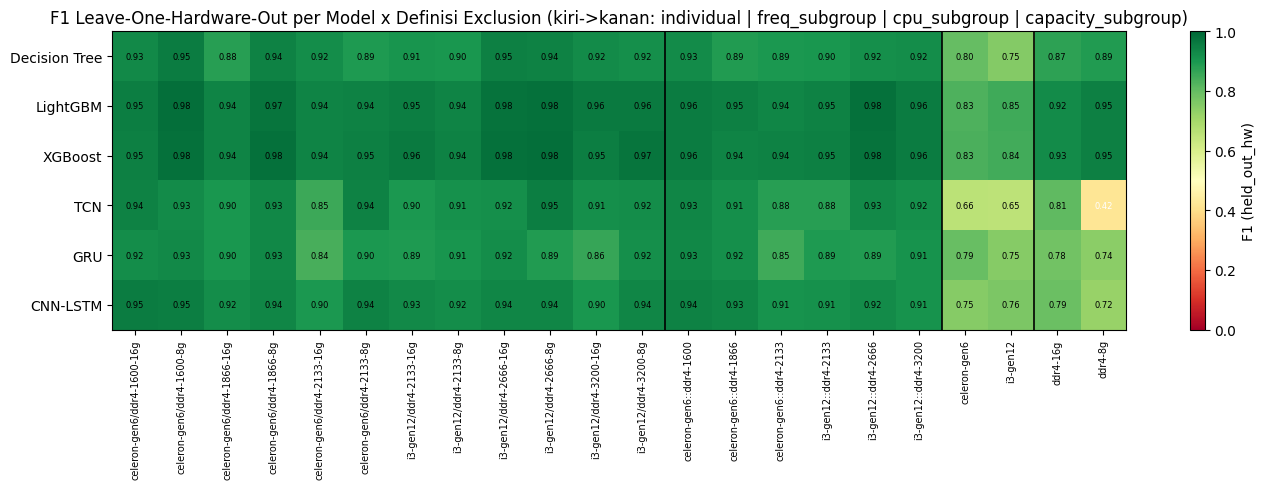


Total baris hasil NB7: 5280 (1320 baris skenario utama held_out_hw)
Heatmap disimpan: /kaggle/working/nb7_f1_heatmap.png


In [3]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

results = pd.read_csv(RESULTS_PATH)
primary = results[results.scenario == "held_out_hw"].copy()

nb6_results = pd.read_csv(f"{NB6_DIR}/nb6_results.csv")
nb6_indist = nb6_results[nb6_results.scenario == "in_distribution"]
baseline = nb6_indist.groupby("model")["f1"].mean().rename("baseline_f1")

n_seeds_nb6 = nb6_indist["seed"].nunique()
n_seeds_nb7 = primary["seed"].nunique()
print(f"Seeds NB6 (baseline): {n_seeds_nb6} {sorted(nb6_indist['seed'].unique())}")
print(f"Seeds NB7 (held_out_hw): {n_seeds_nb7} {sorted(primary['seed'].unique())}")

print(f"\n Baseline in-distribution (NB6), rata-rata {n_seeds_nb6} seed, per model ")
print(baseline.reindex(MODEL_NAMES).to_string())

agg = (primary.groupby(["exclusion_kind", "exclusion_name", "model"])["f1"]
       .agg(["mean", "std", "count"]).reset_index())
agg = agg.merge(baseline, on="model", how="left")
agg["pct_drop_vs_baseline"] = (agg["baseline_f1"] - agg["mean"]) / agg["baseline_f1"] * 100

print("\n RINGKASAN F1 (skenario held_out_hw) PER MODEL x EXCLUSION, dengan %drop vs baseline NB6 ")
print(f"(mean/std dihitung atas {n_seeds_nb7} seed; %drop positif = performa turun dibanding in-distribution)")
for kind in ["individual", "freq_subgroup", "cpu_subgroup", "capacity_subgroup"]:
    print(f"\n--- {kind} ---")
    sub = agg[agg.exclusion_kind == kind].copy()
    sub["f1_fmt"] = sub["mean"].round(4).astype(str) + " +/- " + sub["std"].round(4).astype(str)
    for model in MODEL_NAMES:
        block = sub[sub.model == model].sort_values("exclusion_name")
        for _, r in block.iterrows():
            print(f"  {model:14s} {r['exclusion_name']:42s} f1={r['f1_fmt']:18s} "
                  f"drop_vs_baseline={r['pct_drop_vs_baseline']:+6.1f}%")

print("\n subgrup-CPU (padanan langsung Fig. 10 paper, klaim 19,2% penurunan)")
cpu_rows = agg[agg.exclusion_kind == "cpu_subgroup"].sort_values(["exclusion_name", "model"])
print(cpu_rows[["exclusion_name", "model", "mean", "pct_drop_vs_baseline"]].to_string(index=False))

# --- Heatmap tunggal: model x seluruh 22 exclusion, dikelompokkan per kind ---
kind_order = ["individual", "freq_subgroup", "cpu_subgroup", "capacity_subgroup"]
excl_order = (agg[["exclusion_kind", "exclusion_name"]].drop_duplicates()
              .assign(_k=lambda d: d["exclusion_kind"].map({k: i for i, k in enumerate(kind_order)}))
              .sort_values(["_k", "exclusion_name"])["exclusion_name"].tolist())

pivot = agg.pivot(index="model", columns="exclusion_name", values="mean").reindex(
    index=MODEL_NAMES, columns=excl_order
)

fig, ax = plt.subplots(figsize=(max(14, len(excl_order) * 0.55), 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c.split("::", 1)[-1] for c in pivot.columns], rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6,
                     color="white" if val < 0.45 else "black")
# garis pemisah antar-kind
counts = agg[["exclusion_kind", "exclusion_name"]].drop_duplicates()["exclusion_kind"].map(
    {k: i for i, k in enumerate(kind_order)}
)
boundary = 0
for kind in kind_order[:-1]:
    boundary += (agg[agg.exclusion_kind == kind]["exclusion_name"].nunique())
    ax.axvline(boundary - 0.5, color="black", linewidth=1.2)
fig.colorbar(im, label="F1 (held_out_hw)")
ax.set_title("F1 Leave-One-Hardware-Out per Model x Definisi Exclusion "
             "(kiri->kanan: individual | freq_subgroup | cpu_subgroup | capacity_subgroup)")
plt.tight_layout()
plt.savefig("/kaggle/working/nb7_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal baris hasil NB7: {len(results)} ({len(primary)} baris skenario utama held_out_hw)")
print("Heatmap disimpan: /kaggle/working/nb7_f1_heatmap.png")

## Diagnostik (opsional) -- Investigasi Anomali seed=43 pada `cap::ddr4-8g`

Di Sel 5, tiga model DL (TCN, GRU, CNN-LSTM) menunjukkan std yang jauh lebih besar dari baris lain untuk exclusion `cap::ddr4-8g` (std 0,22-0,30 vs biasanya 0,01-0,08), didorong oleh F1 yang anjlok drastis (0,19-0,35) khusus di `seed=43` -- sementara Decision Tree/LightGBM/XGBoost tetap stabil (~0,94-0,96) di kombinasi (exclusion, seed) yang identik. Sel ini melatih ulang HANYA ketiga model DL itu untuk `seed=43` (bermasalah) vs `seed=44` (kontrol, normal di Sel 3), dan mencetak: (1) komposisi kelas fit/calib hasil split, (2) jumlah epoch berhenti & loss akhir (indikasi training tidak konvergen), (3) distribusi probabilitas kalibrasi (indikasi model kolaps/terlalu percaya diri), (4) berapa sel tabel ekonomi yang jatuh ke prior fallback 0,5 karena `n_ik=0`, dan (5) confusion matrix pada test `held_out_hw`. Tidak menyentuh `nb7_results.csv` -- murni untuk investigasi, tidak mengubah hasil yang sudah ada.

In [4]:
from sklearn.metrics import confusion_matrix

# 
# DIAGNOSTIK (opsional, tidak menyentuh nb7_results.csv): seed=43 vs seed=44 (kontrol)
# untuk exclusion cap::ddr4-8g -- menyelidiki kenapa TCN/GRU/CNN-LSTM anjlok drastis
# (F1 0.19-0.35) khusus di seed=43, sementara Decision Tree/LightGBM/XGBoost tetap
# stabil (~0.94-0.96) pada kombinasi (exclusion, seed) yang sama persis.
# 
DIAG_EXCLUSION = "cap::ddr4-8g"
DIAG_SEEDS = [43, 44]  # 43 = bermasalah (F1 anjlok di Sel 3), 44 = kontrol (normal di Sel 3)
DIAG_MODELS = ["TCN", "GRU", "CNN-LSTM"]

path_to_is_ransomware = features.drop_duplicates("path").set_index("path")["is_ransomware"]

excl_combos, excl_kind = EXCLUSION_GROUPS[DIAG_EXCLUSION]
pool_df = original_split[~original_split["combo_id"].isin(excl_combos)]
heldout_df = original_split[original_split["combo_id"].isin(excl_combos)]

print(f" Distribusi kelas pool exclusion={DIAG_EXCLUSION} ({len(pool_df)} eksekusi) ")
print(pool_df["class"].value_counts().sort_index().to_string())
pool_is_r = pool_df["path"].map(path_to_is_ransomware)
print(f"Rasio ransomware:benign di pool = {pool_is_r.mean():.3f} : {1 - pool_is_r.mean():.3f}")

print("\n Perbandingan komposisi fit/calib split, seed bermasalah vs kontrol ")
for seed in DIAG_SEEDS:
    fit_df, calib_df = train_test_split(pool_df, test_size=0.20, stratify=pool_df["class"], random_state=seed)
    fit_is_r = fit_df["path"].map(path_to_is_ransomware)
    calib_is_r = calib_df["path"].map(path_to_is_ransomware)
    print(f"\n--- seed={seed} ---")
    print(f"fit  : {len(fit_df)} eksekusi (ransomware={int(fit_is_r.sum())}, benign={int((1 - fit_is_r).sum())})")
    print(f"calib: {len(calib_df)} eksekusi (ransomware={int(calib_is_r.sum())}, benign={int((1 - calib_is_r).sum())})")
    print("calib per kelas:")
    print(calib_df["class"].value_counts().sort_index().to_string())

# --- retrain 3 model DL utk kedua seed, tangkap training history + distribusi probabilitas + confusion matrix ---
X_heldout_raw_by_model = {}
for name in DIAG_MODELS:
    params = selected_params[name]
    grid = checkpoints_for_step(params["step"])
    K, alpha, beta = params["economy_K"], params["economy_alpha"], params["economy_beta"]
    X_heldout_raw, y_heldout = build_sequences(features, heldout_df["path"], grid, ALL_FEATURE_NAMES)

    for seed in DIAG_SEEDS:
        fit_df, calib_df = train_test_split(pool_df, test_size=0.20, stratify=pool_df["class"], random_state=seed)
        X_fit_raw, y_fit = build_sequences(features, fit_df["path"], grid, ALL_FEATURE_NAMES)
        X_calib_raw, y_calib = build_sequences(features, calib_df["path"], grid, ALL_FEATURE_NAMES)

        X_fit_log = apply_log1p(X_fit_raw, LOG1P_IDX)
        scaler = StandardScaler().fit(X_fit_log.reshape(-1, X_fit_log.shape[-1]))

        def prep(Xraw):
            return scale_3d(apply_log1p(Xraw, LOG1P_IDX), scaler)

        X_fit, X_calib, X_heldout = prep(X_fit_raw), prep(X_calib_raw), prep(X_heldout_raw)
        y_fit_seq = np.repeat(y_fit[:, None, None], len(grid), axis=1).astype("float32")
        y_calib_seq = np.repeat(y_calib[:, None, None], len(grid), axis=1).astype("float32")

        keras.utils.set_random_seed(seed)
        if name == "TCN":
            dilations = tuple(2 ** i for i in range(params["tcn_n_blocks"]))
            dl_model = build_tcn_hpo(len(grid), X_fit.shape[-1], params["tcn_filters"],
                                      params["tcn_kernel_size"], dilations, params["tcn_dropout"])
            lr = params["tcn_lr"]
        elif name == "GRU":
            dl_model = build_gru_hpo(len(grid), X_fit.shape[-1], params["gru_units"],
                                      params["gru_n_layers"], params["gru_dropout"])
            lr = params["gru_lr"]
        else:
            dl_model = build_cnn_lstm_hpo(len(grid), X_fit.shape[-1], params["cnnlstm_conv_filters"],
                                           params["cnnlstm_kernel_size"], params["cnnlstm_lstm_units"],
                                           params["cnnlstm_dropout"])
            lr = params["cnnlstm_lr"]

        dl_model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy")
        es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
        history = dl_model.fit(X_fit, y_fit_seq, validation_data=(X_calib, y_calib_seq),
                                epochs=50, batch_size=32, callbacks=[es], verbose=0)

        probs_calib = dl_model.predict(X_calib, verbose=0)[:, :, 0]
        probs_heldout = dl_model.predict(X_heldout, verbose=0)[:, :, 0]

        bin_edges, prior1, fp_rate, fn_rate = build_economy_table(probs_calib, y_calib, K, beta)
        n_fallback = sum(1 for v in prior1.values() if v == 0.5)
        y_pred, dtime = simulate_decisions(probs_heldout, grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta)
        f1 = f1_score(y_heldout, y_pred, zero_division=0)
        cm = confusion_matrix(y_heldout, y_pred)

        n_epochs = len(history.history["loss"])
        tag = "BERMASALAH" if seed == 43 else "kontrol"
        print(f"\n {name} seed={seed} ({tag}) ")
        print(f"epoch berhenti: {n_epochs}/50 (patience=8) | "
              f"loss akhir: train={history.history['loss'][-1]:.4f} val={history.history['val_loss'][-1]:.4f}")
        print(f"distribusi prob kalibrasi (semua checkpoint gabung): "
              f"min={probs_calib.min():.4f} max={probs_calib.max():.4f} "
              f"mean={probs_calib.mean():.4f} std={probs_calib.std():.4f}")
        print(f"  fraksi prob calib < 0.01: {(probs_calib < 0.01).mean():.3f} | "
              f"fraksi > 0.99: {(probs_calib > 0.99).mean():.3f}")
        print(f"  sel bin ekonomi yang fallback ke prior=0.5 (n_ik=0): {n_fallback}/{len(prior1)}")
        print(f"F1 held_out_hw = {f1:.4f} | confusion matrix "
              f"(baris=aktual[benign,ransomware], kolom=prediksi):\n{cm}")
        print(f"  {int(y_pred.sum())} dari {len(y_pred)} diprediksi ransomware "
              f"(aktual ransomware={int(y_heldout.sum())})")

 Distribusi kelas pool exclusion=cap::ddr4-8g (719 eksekusi) 
class
AESCrypt    60
Conti       60
Darkside    60
Firefox     60
Idle        60
LockBit     59
Office      60
REvil       60
Ryuk        60
SDelete     60
WannaCry    60
Zip         60
Rasio ransomware:benign di pool = 0.499 : 0.501

 Perbandingan komposisi fit/calib split, seed bermasalah vs kontrol 

--- seed=43 ---
fit  : 575 eksekusi (ransomware=287, benign=288)
calib: 144 eksekusi (ransomware=72, benign=72)
calib per kelas:
class
AESCrypt    12
Conti       12
Darkside    12
Firefox     12
Idle        12
LockBit     12
Office      12
REvil       12
Ryuk        12
SDelete     12
WannaCry    12
Zip         12

--- seed=44 ---
fit  : 575 eksekusi (ransomware=287, benign=288)
calib: 144 eksekusi (ransomware=72, benign=72)
calib per kelas:
class
AESCrypt    12
Conti       12
Darkside    12
Firefox     12
Idle        12
LockBit     12
Office      12
REvil       12
Ryuk        12
SDelete     12
WannaCry    12
Zip         12


I0000 00:00:1790077344.315720      77 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



 TCN seed=43 (BERMASALAH) 
epoch berhenti: 38/50 (patience=8) | loss akhir: train=0.1238 val=0.4054
distribusi prob kalibrasi (semua checkpoint gabung): min=0.0000 max=1.0000 mean=0.5099 std=0.4525
  fraksi prob calib < 0.01: 0.294 | fraksi > 0.99: 0.234
  sel bin ekonomi yang fallback ke prior=0.5 (n_ik=0): 0/6
F1 held_out_hw = 0.4464 | confusion matrix (baris=aktual[benign,ransomware], kolom=prediksi):
[[358   2]
 [256 104]]
  106 dari 720 diprediksi ransomware (aktual ransomware=360)

 TCN seed=44 (kontrol) 
epoch berhenti: 35/50 (patience=8) | loss akhir: train=0.1281 val=0.3480
distribusi prob kalibrasi (semua checkpoint gabung): min=0.0000 max=1.0000 mean=0.4911 std=0.4472
  fraksi prob calib < 0.01: 0.266 | fraksi > 0.99: 0.171
  sel bin ekonomi yang fallback ke prior=0.5 (n_ik=0): 0/6
F1 held_out_hw = 0.2998 | confusion matrix (baris=aktual[benign,ransomware], kolom=prediksi):
[[357   3]
 [296  64]]
  67 dari 720 diprediksi ransomware (aktual ransomware=360)

 GRU seed=43 (BER